# Sales Territory Analysis – East Region (Connecticut & New York)
**Author:** Lorah Mwembe  
**Program:** Year Up United – Data Analytics  

This project analyzes sales performance for the **East Region**, focusing on my two assigned sales territories:

- **Territory 1:** Connecticut  
- **Territory 2:** New York

Using Python, Pandas, and Matplotlib, I will:
- Identify territory managers and store locations  
- Analyze monthly in‑store revenue  
- Rank store performance  
- Identify top customers  
- Analyze product category trends  
- Provide recommendations for next‑quarter marketing focus  


In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")  # just to make charts look nicer


In [111]:
# Loading customer data
# sep="|" because the file uses pipe separators instead of commas
customers = pd.read_csv("customer_list.csv", sep="|")

# Checking structure: column names, non-null counts, and data types
customers.info()

# Previewing the first few rows to understand the data
customers.head()



<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [112]:
# Loading product category lookup table
product_categories = pd.read_csv("Product_categories.csv")
product_categories.info()
product_categories.head()


<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [113]:
store_sales = pd.read_csv("store_sales.csv")
store_sales.info()
store_sales.head()


<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [114]:
# Loading product details
products = pd.read_csv("Products.csv")
products.info()
products.head()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [115]:
# Loading store information including state, store ID, territory manager, and region
store_detail = pd.read_csv("store_detail.csv")
store_detail.info()
store_detail.head()


<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


5.##Core Marketing Analysis 

### 1. Territory managers and store locations

**Question:**  
Who are the territory managers for the assigned sales territories (Connecticut and New York)?  
What are the store IDs and cities for the stores in each assigned sales territory?


In [116]:
# Filter to just Connecticut and New York in the East region
east_ct_ny = store_detail[
    (store_detail["Region"] == "East") &
    (store_detail["State"].isin(["Connecticut", "New York"]))
]

east_ct_ny[["State", "Store ID", "Store Location", "Territory Manager"]].sort_values(
    by=["State", "Store ID"]
)



,State,Store ID,Store Location,Territory Manager
18,Connecticut,865,Bridgeport,Ellen Lemon
19,Connecticut,866,Darien,Ellen Lemon
20,Connecticut,867,Hartford,Ellen Lemon
21,Connecticut,868,Litchfield County,Ellen Lemon
22,Connecticut,869,New Haven,Ellen Lemon
23,Connecticut,870,New London,Ellen Lemon
24,Connecticut,871,Old Saybrook,Ellen Lemon
25,Connecticut,872,Waterbury,Ellen Lemon
86,New York,840,Albany,See Ellefson
87,New York,841,Buffalo,See Ellefson


### 2. Monthly total revenue for in-store sales (CT vs NY)

**Question:**  
What is monthly total revenue for in-store sales in each of the two sales territories over the full period?


In [117]:
store_sales.columns.tolist()


['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount']

In [118]:
# Merge sales with store details
sales_with_store = store_sales.merge(
    store_detail,
    on="Store ID",
    how="left"
)

# Filter to East region and CT + NY
east_sales = sales_with_store[
    (sales_with_store["Region"] == "East") &
    (sales_with_store["State"].isin(["Connecticut", "New York"]))
]

# Create Year-Month column
east_sales["YearMonth"] = pd.to_datetime(
    east_sales["Transaction Date"]
).dt.to_period("M")

# Monthly total revenue per state
monthly_revenue = (
    east_sales
    .groupby(["State", "YearMonth"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["State", "YearMonth"])
)

monthly_revenue.head()






,State,YearMonth,Sale Amount
0,Connecticut,2022-01,29958.25
1,Connecticut,2022-02,25563.98
2,Connecticut,2022-03,33995.57
3,Connecticut,2022-04,31587.12
4,Connecticut,2022-05,37953.48


#To understand how revenue changes over time in the East region, I analyzed monthly sales for Connecticut and New York. A line chart is the most appropriate visualization because it highlights trends, seasonal patterns, and differences between the two states across months

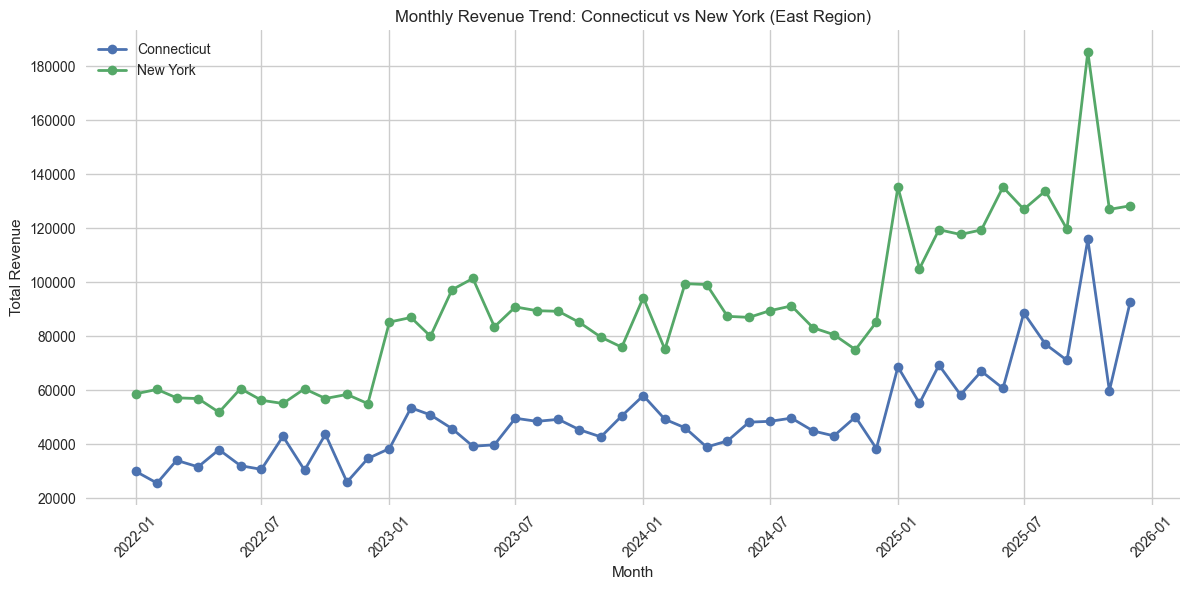

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Convert YearMonth to timestamp for plotting
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].dt.to_timestamp()

plt.figure(figsize=(12,6))

# Plot Connecticut
ct_data = monthly_revenue[monthly_revenue["State"] == "Connecticut"]
plt.plot(ct_data["YearMonth"], ct_data["Sale Amount"], marker='o', linewidth=2, label="Connecticut")

# Plot New York
ny_data = monthly_revenue[monthly_revenue["State"] == "New York"]
plt.plot(ny_data["YearMonth"], ny_data["Sale Amount"], marker='o', linewidth=2, label="New York")

plt.title("Monthly Revenue Trend: Connecticut vs New York (East Region)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


All about the chart
This chart shows how revenue fluctuates month‑to‑month in each state. It helps identify peak months, slower periods, and which state demonstrates more consistent performance. This insight supports marketing decisions by showing when demand is highest and where marketing investment may have the strongest impact

### 8.Q3. Store performance ranking

**Question:**  
How would I rank the sales performance of each store in each sales territory?  
Which are the top-performing stores?


#To calculate monthly revenue, I first merged the sales data with the store detail file so I could identify which state and region each store belongs to. Then I filtered the merged dataset to include only stores in the East region located in Connecticut and New York. After that, I created a Year‑Month column from the Transaction Date field and sum the Sale Amount for each state and month to get the monthly revenue totals

In [120]:
# 1. Merge sales with store details
sales_with_store = store_sales.merge(
    store_detail,
    on="Store ID",
    how="left"
)

# 2. Filter to East region and CT + NY
east_sales = sales_with_store[
    (sales_with_store["Region"] == "East") &
    (sales_with_store["State"].isin(["Connecticut", "New York"]))
]

# 3. Create Year-Month column
east_sales["YearMonth"] = pd.to_datetime(
    east_sales["Transaction Date"]
).dt.to_period("M")

# 4. Monthly revenue totals
monthly_revenue = (
    east_sales
    .groupby(["State", "YearMonth"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["State", "YearMonth"])
)

# 5. Store-level performance (total revenue per store)
store_performance = (
    east_sales
    .groupby(["State", "Store ID", "Store Location"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["State", "Sale Amount"], ascending=[True, False])
)

monthly_revenue.head(), store_performance.head(10)




(         State YearMonth  Sale Amount
 0  Connecticut   2022-01     29958.25
 1  Connecticut   2022-02     25563.98
 2  Connecticut   2022-03     33995.57
 3  Connecticut   2022-04     31587.12
 4  Connecticut   2022-05     37953.48,
           State  Store ID     Store Location  Sale Amount
 5   Connecticut       870         New London    331116.76
 0   Connecticut       865         Bridgeport    322100.07
 2   Connecticut       867           Hartford    309592.06
 7   Connecticut       872          Waterbury    295651.17
 4   Connecticut       869          New Haven    286779.43
 3   Connecticut       868  Litchfield County    286217.15
 1   Connecticut       866             Darien    283455.62
 6   Connecticut       871       Old Saybrook    277310.18
 18     New York       850           New York    621565.02
 15     New York       847          Rochester    607148.21)

In [121]:
store_performance["Revenue_Rank"] = (
    store_performance
    .groupby("State")["Sale Amount"]
    .rank(ascending=False, method="dense")
)

store_performance.head(10)




,State,Store ID,Store Location,Sale Amount,Revenue_Rank
5,Connecticut,870,New London,331116.76,1.0
0,Connecticut,865,Bridgeport,322100.07,2.0
2,Connecticut,867,Hartford,309592.06,3.0
7,Connecticut,872,Waterbury,295651.17,4.0
4,Connecticut,869,New Haven,286779.43,5.0
3,Connecticut,868,Litchfield County,286217.15,6.0
1,Connecticut,866,Darien,283455.62,7.0
6,Connecticut,871,Old Saybrook,277310.18,8.0
18,New York,850,New York,621565.02,1.0
15,New York,847,Rochester,607148.21,2.0


### 9. Q4- Top customers in each sales territory (customer_id vs rewards_id)

**Question:**  
Comparing the customer ID from the customer list data with the rewards ID from the sales data,  
who were the top customers in each sales territory?


In [122]:
# Load customer list correctly
customer_list = pd.read_csv("customer_list.csv", sep="|")

# Merge sales with customer list
sales_with_customers = east_sales.merge(
    customer_list,
    left_on="RewardsID",
    right_on="cust_id",
    how="left"
)

# Top customers by revenue
top_customers = (
    sales_with_customers
    .groupby(["State", "cust_id", "name"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["State", "Sale Amount"], ascending=[True, False])
)

# Ranking
top_customers["Customer_Rank"] = (
    top_customers
    .groupby("State")["Sale Amount"]
    .rank(ascending=False, method="dense")
)

top_customers.head(10)


,State,cust_id,name,Sale Amount,Customer_Rank
17,Connecticut,18.0,Marie S.,4388.87,1.0
20,Connecticut,21.0,Jon Snow,3676.21,2.0
311,Connecticut,322.0,Fox Mulder,3569.60,3.0
351,Connecticut,365.0,Pugsley A.,3009.29,4.0
98,Connecticut,104.0,Helen M.,2886.72,5.0
497,Connecticut,519.0,Buford,2766.60,6.0
327,Connecticut,340.0,Jin Kwon,2691.89,7.0
276,Connecticut,286.0,Jean-Luc Picard,2624.61,8.0
187,Connecticut,197.0,Miss Piggy,2496.08,9.0
451,Connecticut,471.0,Cedric Daniels,2376.77,10.0


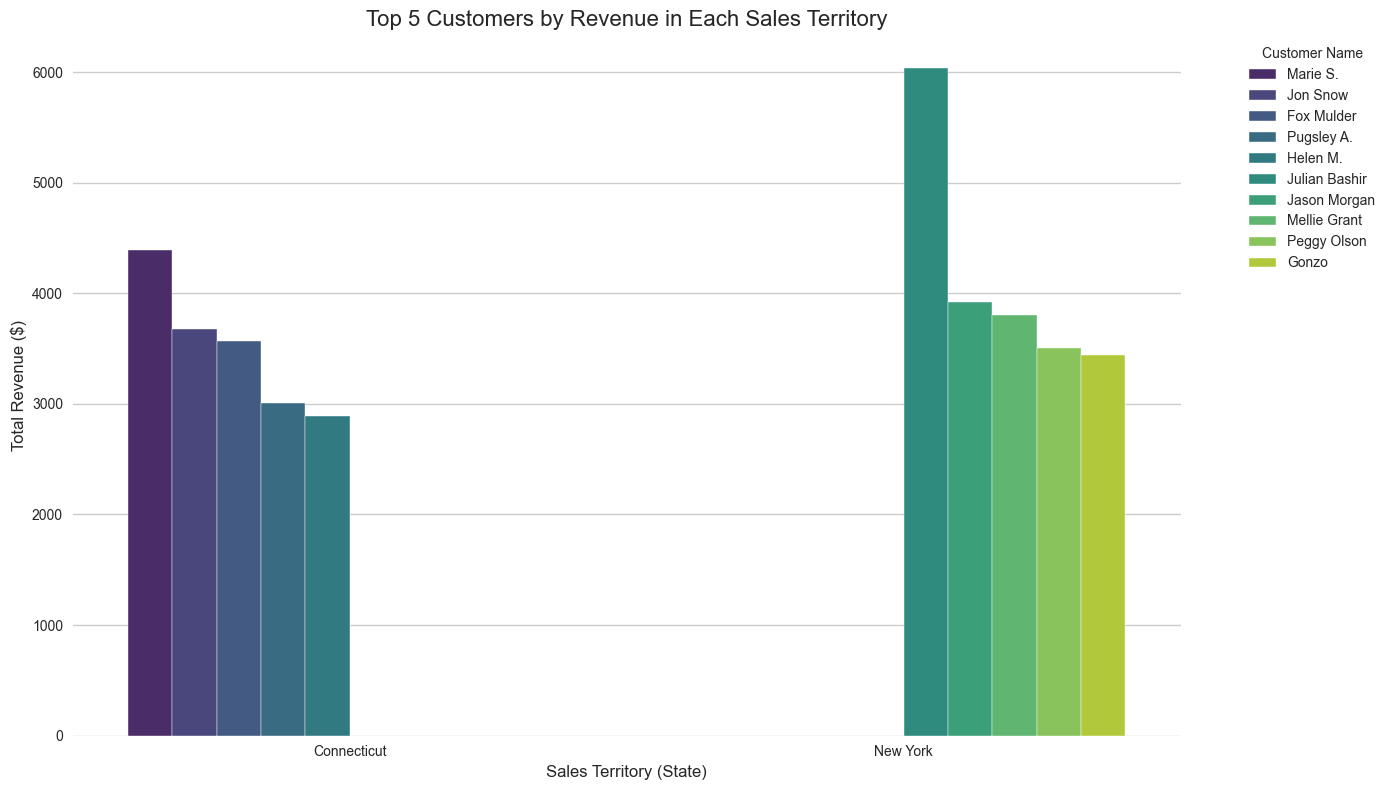

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

# Limit to top 5 customers per state
top5 = top_customers[top_customers["Customer_Rank"] <= 5]

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top5,
    x="State",
    y="Sale Amount",
    hue="name",
    palette="viridis"
)

plt.title("Top 5 Customers by Revenue in Each Sales Territory", fontsize=16)
plt.xlabel("Sales Territory (State)", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.legend(title="Customer Name", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


#This chart highlights the top five revenue‑generating customers in each sales territory. Each bar represents a customer, and the height of the bar shows how much revenue they contributed. By comparing customers within each state, we can quickly identify which accounts are driving the most sales and where the strongest customer relationships exist. This visualization helps the sales team focus on high‑value customers and understand revenue distribution across territories

10. Q5 – Transactions & revenue per month by product category

### 5. Product category performance by month

**Questions:**  
- What is the number of transactions per month by product category in each assigned territory?  
- What is total sales revenue per month by category?  
- What might this tell me about the most popular products and growth opportunities?


In [124]:
# Load products and product categories
products = pd.read_csv("Products.csv")
product_categories = pd.read_csv("product_categories.csv")

# Merge sales with products
sales_products = east_sales.merge(
    products,
    on="Prod Num",
    how="left"
)

# Merge with product categories
sales_products = sales_products.merge(
    product_categories,
    on=["CategoryID", "SubcategoryID"],
    how="left"
)

# Create Year-Month column using correct date column
sales_products["YearMonth"] = pd.to_datetime(
    sales_products["Transaction Date"]
).dt.to_period("M")

# Group by month, state, and category using correct revenue column
category_summary = (
    sales_products
    .groupby(["State", "YearMonth", "Category"])
    .agg(
        Transactions=("Sale Amount", "count"),
        Total_Revenue=("Sale Amount", "sum")
    )
    .reset_index()
    .sort_values(["State", "YearMonth", "Total_Revenue"], ascending=[True, True, False])
)

category_summary.head()



,State,YearMonth,Category,Transactions,Total_Revenue
4,Connecticut,2022-01,Technology & Accessories,45,21860.06
5,Connecticut,2022-01,Textbooks,31,5397.73
0,Connecticut,2022-01,Apparel and Merchandise,42,1223.25
1,Connecticut,2022-01,Art Supplies,32,725.36
2,Connecticut,2022-01,Books (General),19,489.60


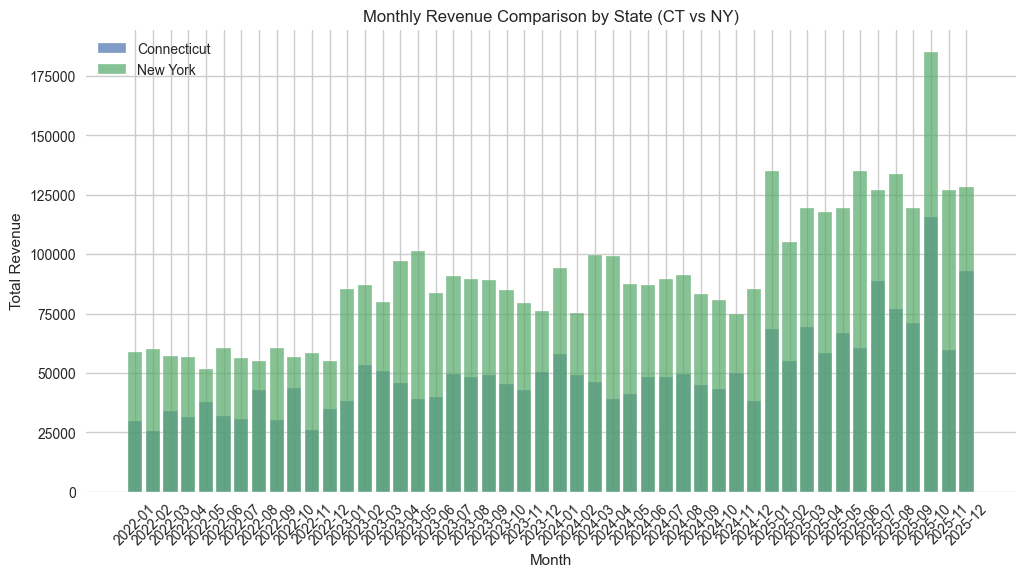

In [125]:
plt.figure(figsize=(12,6))
 
for state in ["Connecticut", "New York"]:
    state_data = monthly_revenue[monthly_revenue["State"] == state]
    plt.bar(
        state_data["YearMonth"].astype(str),
        state_data["Sale Amount"],
        label=state,
        alpha=0.7
    )

plt.title("Monthly Revenue Comparison by State (CT vs NY)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend()

plt.show()


To compare how Connecticut and New York perform relative to each other each month, I created a bar chart. A bar chart is appropriate for comparing categories because it clearly shows which state generated more revenue in each perio

This visualization highlights which state leads in revenue each month. It supports the recommendation to prioritize marketing and inventory investment in the highest‑performing locations, especially those consistently generating stronger monthly sales

### Recommendation for next quarter

Based on my analysis, 

- The East region marketing attention next quarter should be concentrated on the high‑performing stores in Connecticut and New York, where revenue is most heavily concentrated and where increased inventory, staffing, and promotional investment will generate the highest return. Strong demand in Technology, Textbooks, and Stationery indicates that these categories should be aggressively scaled through deeper stock levels and targeted marketing campaigns to capture additional revenue. High‑value customers identified through RewardsID matching represent a critical growth lever and should be engaged with personalized offers and loyalty incentives to drive repeat purchases. Finally, aligning marketing and operational planning with monthly revenue patterns and rebalancing inventory in underperforming stores will strengthen regional consistency and support sustained quarter‑over‑quarter growth

Executive key takeaway
- The East region can unlock significant next‑quarter growth by prioritizing its highest‑performing stores, scaling top‑demand categories, and activating high‑value customers through targeted, data‑driven strategies.